# Preparation

In [11]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
from typing import Tuple


def detect_environment():
    """Detect if running in Colab, Kaggle, or local environment"""
    if 'google.colab' in sys.modules:
        return 'colab'
    elif 'kaggle_secrets' in sys.modules or os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        return 'kaggle'
    else:
        return 'local'

def get_base_path(env: str) -> str:
    """Get base path for environment"""
    if env == 'colab':
        return '/content'
    elif env == 'kaggle':
        return '/kaggle'
    else:
      return '../'


ENV = detect_environment()
print(f"Detected environment: {ENV.upper()}")

BASE_PATH = get_base_path(ENV)
print(f"Base path: {BASE_PATH}")

Detected environment: LOCAL
Base path: ../


# Bagian A - Observasi dan Eksperimen

## 1. Tampilkan histogram tiap citra dan analisis distribusi intensitasnya

In [70]:
def visualize_histogram(
    img: np.ndarray, 
    suptitle: str = 'Histogram BGR plot using NumPy'
) -> None:
    """
    img with BGR format
    """
    blue_channel = img[:, :, 0].flatten()
    green_channel = img[:, :, 1].flatten()
    red_channel = img[:, :, 2].flatten()
    
    red_hist, red_bins = np.histogram(
        red_channel, 
        bins=256, 
        range=(0, 256)
    )
    green_hist, green_bins = np.histogram(
        green_channel, 
        bins=256, 
        range=(0, 256)
    )
    blue_hist, blue_bins = np.histogram(
        blue_channel, 
        bins=256, 
        range=(0, 256)
    )

    # Plot the histograms
    fig, axes = plt.subplots(
        nrows=1, 
        ncols=3, 
        figsize=[20, 5], 
        sharex=True, 
        sharey=True
    )
    fig.suptitle(suptitle)
    fig.text(
        x=0.09, 
        y=0.5, 
        s='Jumlah kemunculan', 
        va='center', 
        rotation='vertical'
    )
    fig.text(
        x=0.5, 
        y=0.04, 
        s='Intensitas Warna', 
        ha='center'
    )

    # Use the bin centers for plotting
    axes[0].bar(red_bins[:-1], red_hist, color='red', width=1)
    axes[1].bar(green_bins[:-1], green_hist, color='green', width=1)
    axes[2].bar(blue_bins[:-1], blue_hist, color='blue', width=1)

    plt.show()

In [16]:
imgs_path = [
    f'{BASE_PATH}/assets/face1-s.jpg',
    f'{BASE_PATH}/assets/face2-s.jpg',
    f'{BASE_PATH}/assets/face3-s.jpg'
]

img_objs = [cv2.imread(path) for path in imgs_path]
img_objs

[array([[[210, 215, 200],
         [210, 215, 200],
         [206, 211, 196],
         ...,
         [236, 233, 225],
         [243, 240, 232],
         [249, 246, 238]],
 
        [[213, 218, 203],
         [213, 218, 203],
         [212, 217, 202],
         ...,
         [238, 235, 227],
         [239, 236, 228],
         [239, 236, 228]],
 
        [[202, 207, 192],
         [203, 208, 193],
         [206, 211, 196],
         ...,
         [245, 242, 234],
         [244, 241, 233],
         [242, 239, 231]],
 
        ...,
 
        [[231, 238, 225],
         [229, 236, 223],
         [230, 237, 224],
         ...,
         [199, 136,  76],
         [200, 137,  77],
         [201, 138,  78]],
 
        [[228, 235, 222],
         [226, 233, 220],
         [229, 236, 223],
         ...,
         [199, 136,  76],
         [200, 137,  77],
         [202, 139,  79]],
 
        [[223, 230, 217],
         [223, 230, 217],
         [227, 234, 221],
         ...,
         [200, 137,  77],
  

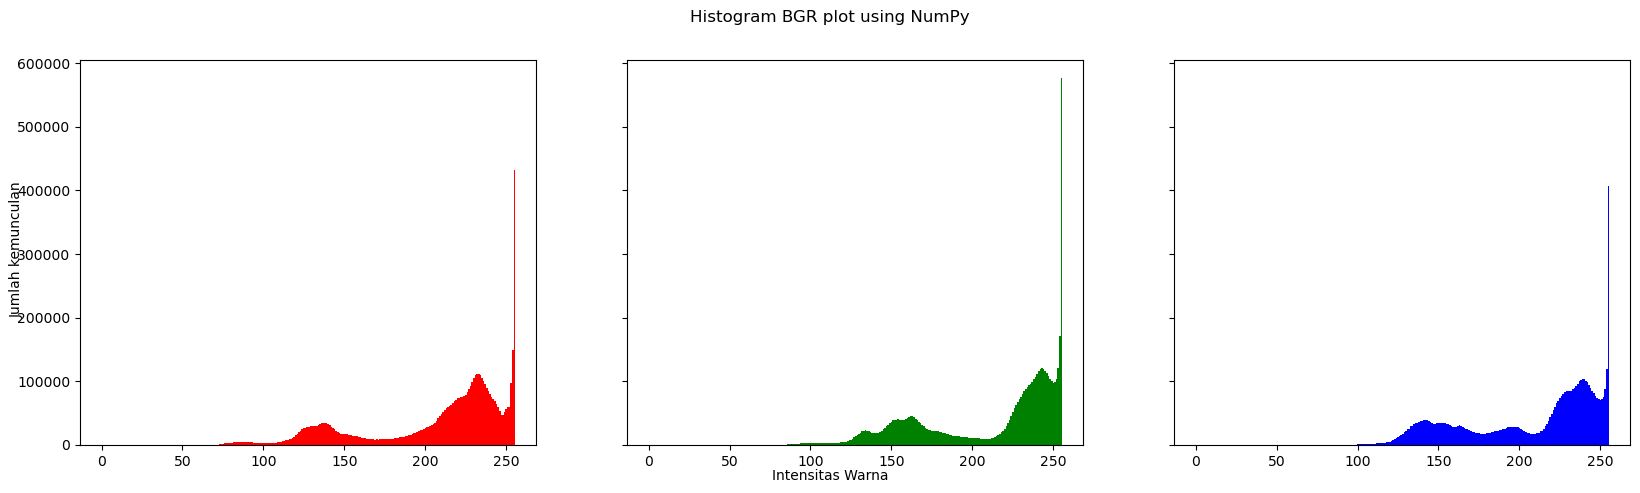

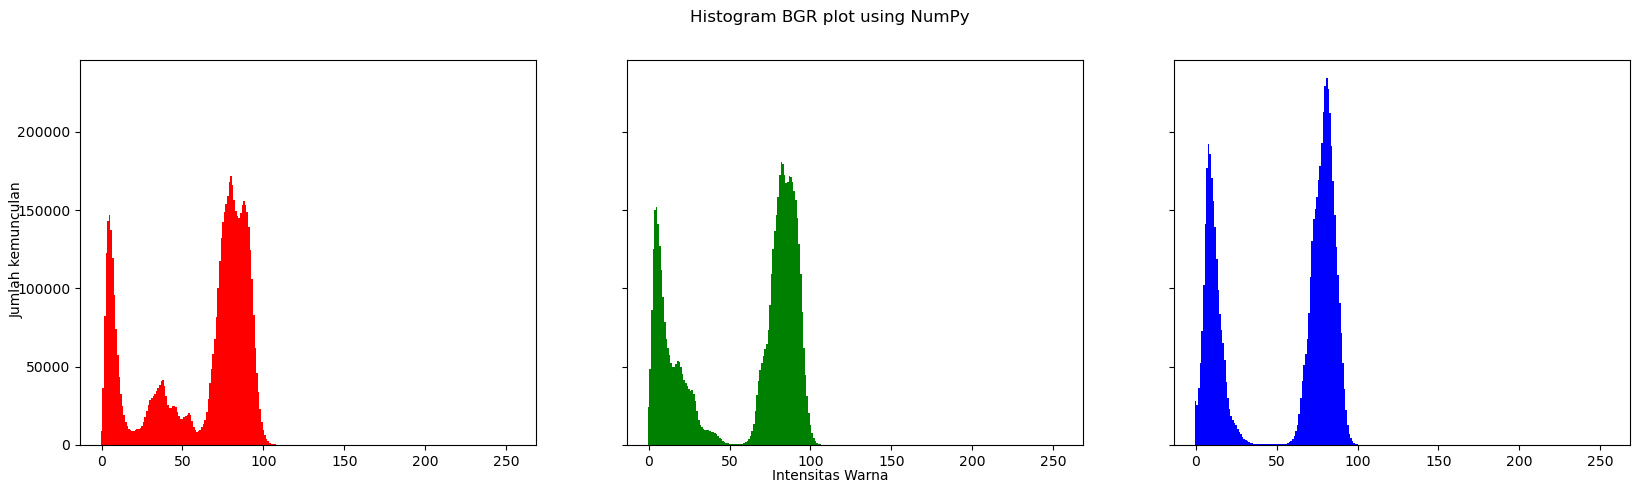

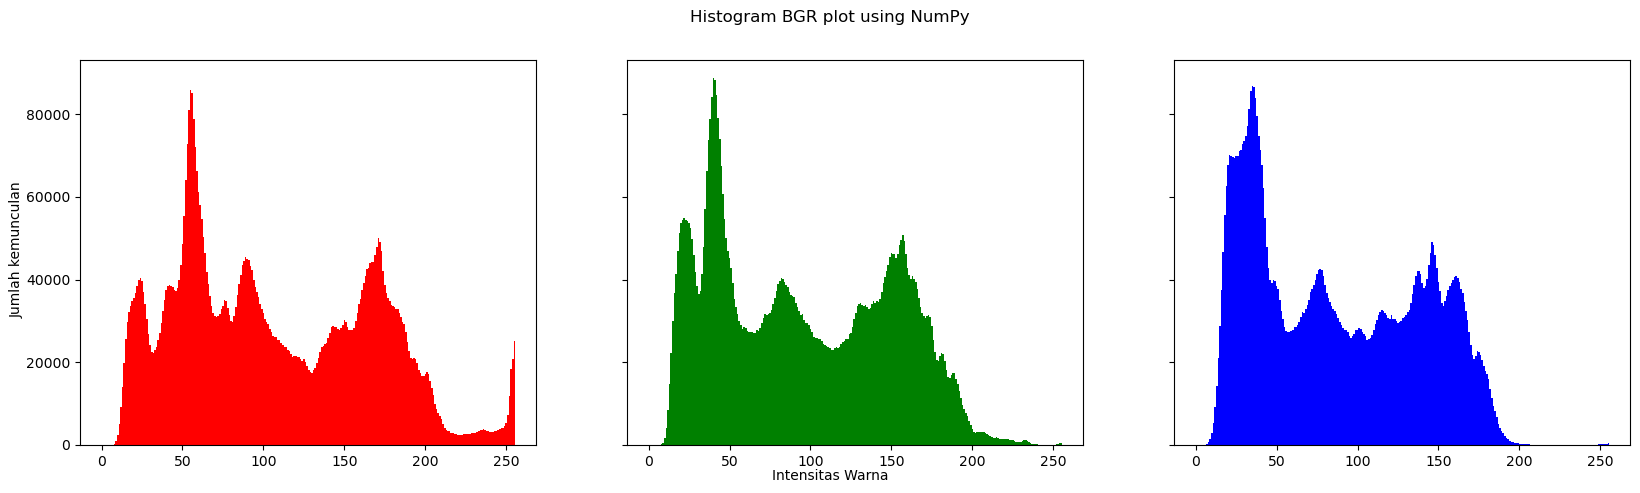

In [17]:
for img in img_objs:
    if img is None:
        raise Exception('Image is not found!')
    
    visualize_histogram(img)

## 2. Terapkan transformasi brightness dan contrast (linear/log brightness)

Tentukan nilai b (brightness) dan a (contrast) yang sesuai agar wajah tampak
natural.

In [18]:
def transformContrastBrightness(
    img: np.ndarray,
    alpha: float = 1.0,
    beta: float = 0.0
) -> np.ndarray:
    """
    Formula:
        g(x, y) = alpha * f(x, y) + beta
    
    Args:
        img (np.ndarray): Input image (grayscale or color, dtype=uint8).
        alpha (float): Contrast factor. 
                       1.0 = no change, >1.0 = higher contrast, 0–1.0 = lower contrast.
        beta (float): Brightness offset. 
                      0 = no change, >0 = brighter, <0 = darker.

    Returns:
        np.ndarray: Adjusted image, dtype=uint8, same shape as input.
    """
    adjusted = alpha * img.astype(np.float32) + beta

    return np.clip(adjusted, 0, 255).astype(np.uint8)

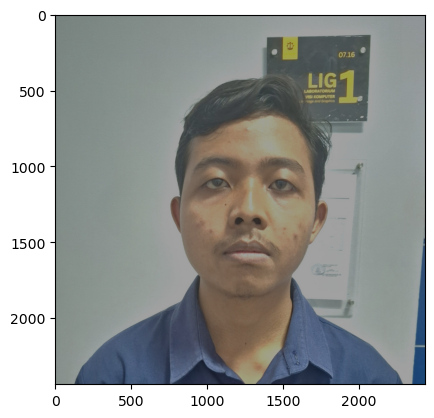

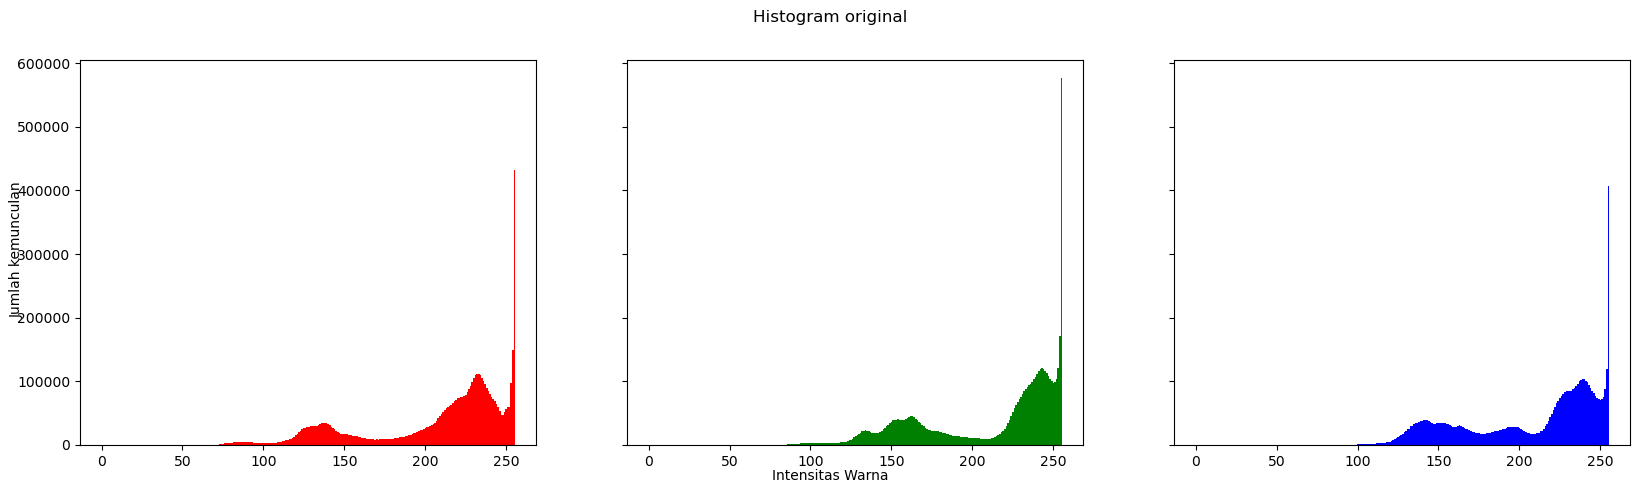

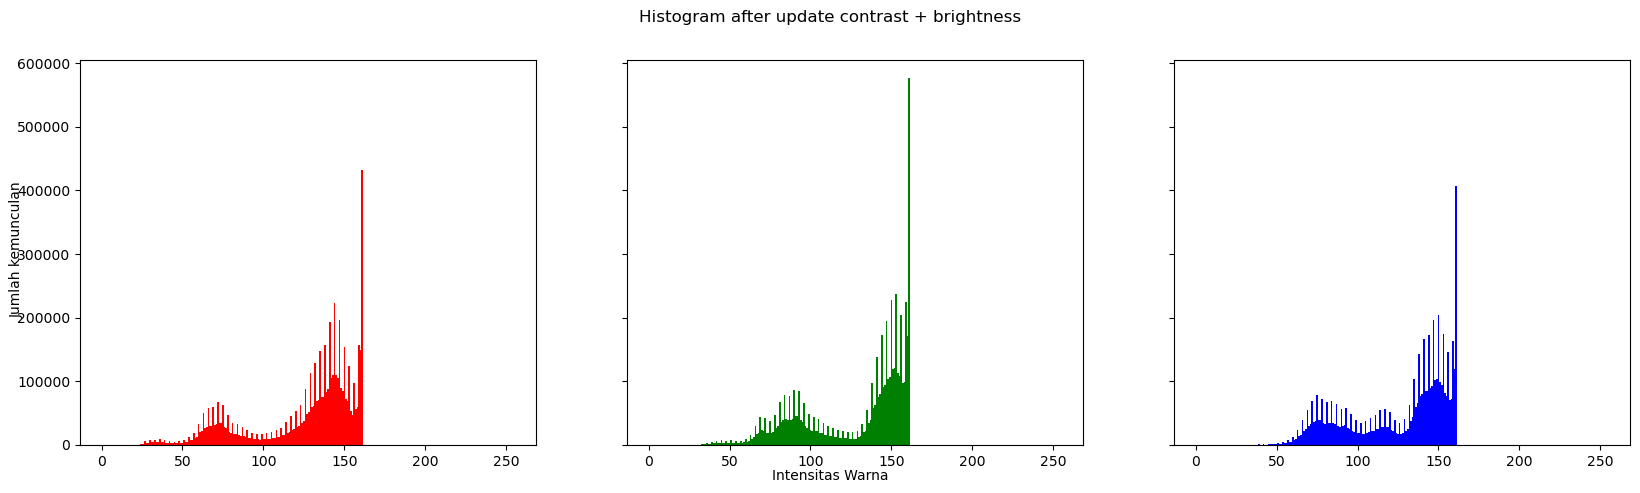

In [71]:
# 1st image
img_1a = transformContrastBrightness(
    img_objs[0],
    alpha=0.75,
    beta=-30
)

img_1a_rgb = cv2.cvtColor(img_1a, cv2.COLOR_BGR2RGB)

plt.imshow(img_1a_rgb)
plt.show()

visualize_histogram(img_objs[0], suptitle='Histogram original')
visualize_histogram(img_1a, suptitle='Histogram after update contrast + brightness')

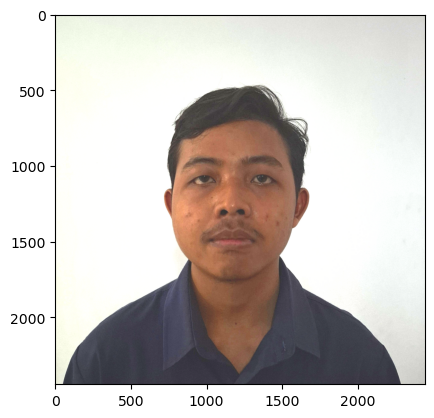

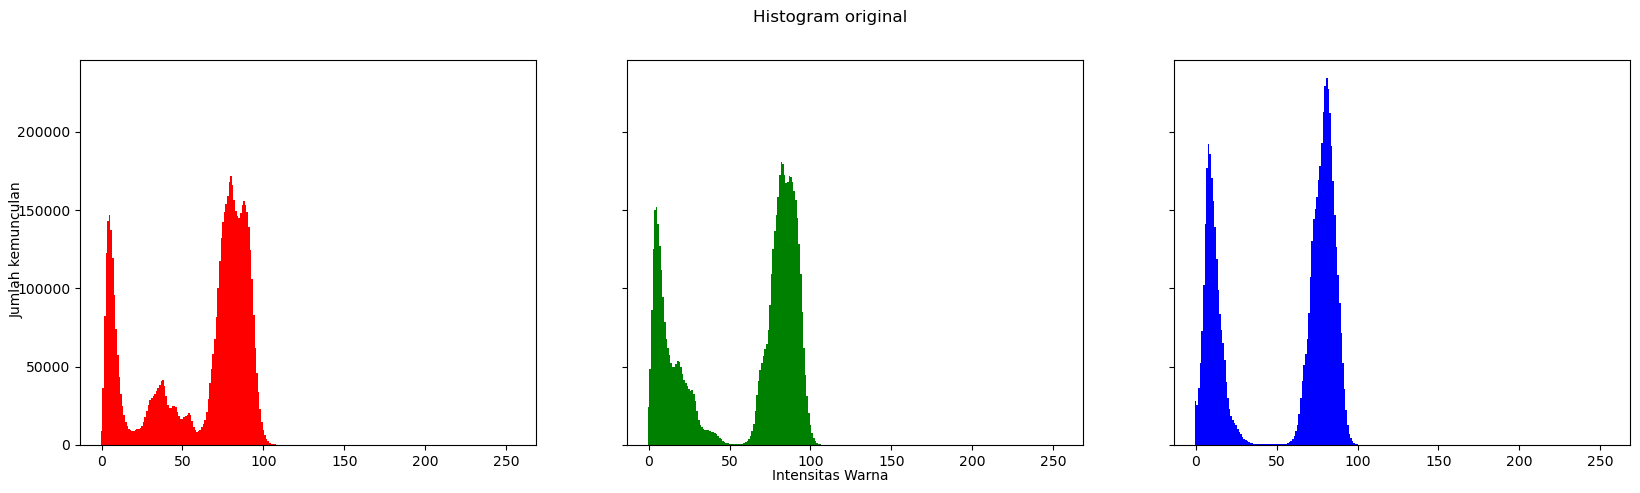

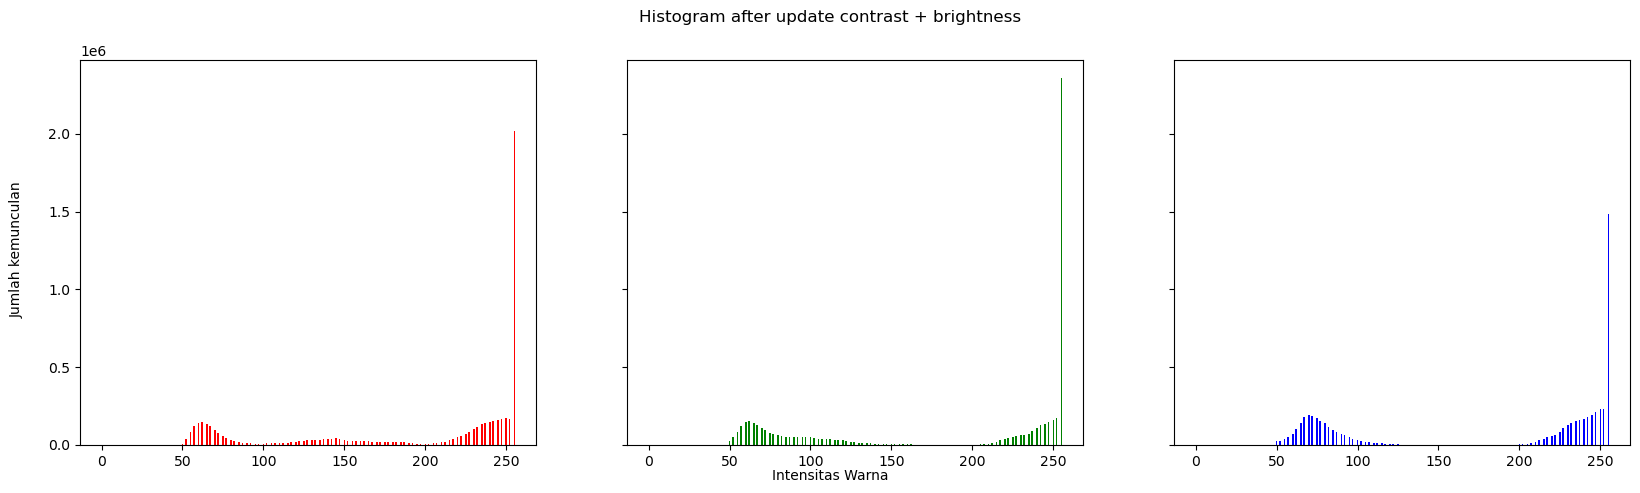

In [72]:
# 2nd image
img_2a = transformContrastBrightness(
    img_objs[1],
    alpha=2.5,
    beta=50
)

img_2a_rgb = cv2.cvtColor(img_2a, cv2.COLOR_BGR2RGB)

plt.imshow(img_2a_rgb)
plt.show()

visualize_histogram(img_objs[1], suptitle='Histogram original')
visualize_histogram(img_2a, suptitle='Histogram after update contrast + brightness')

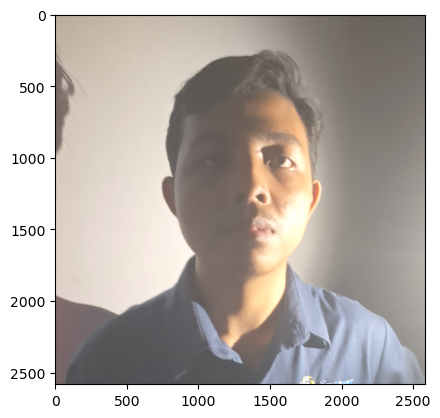

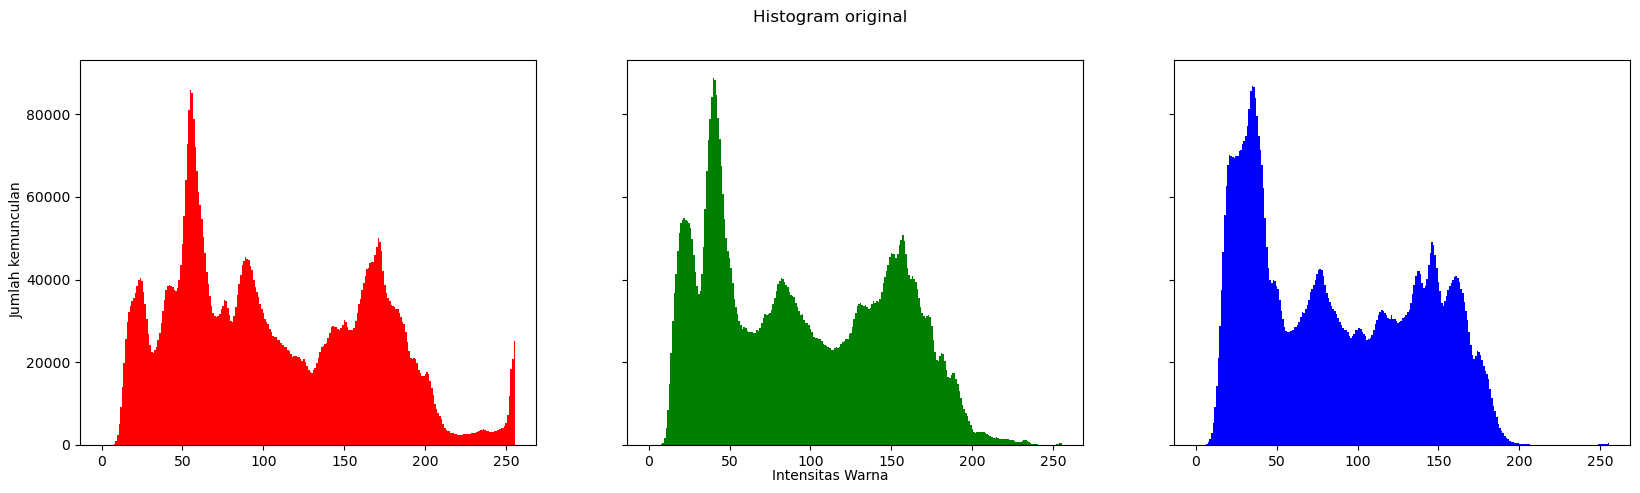

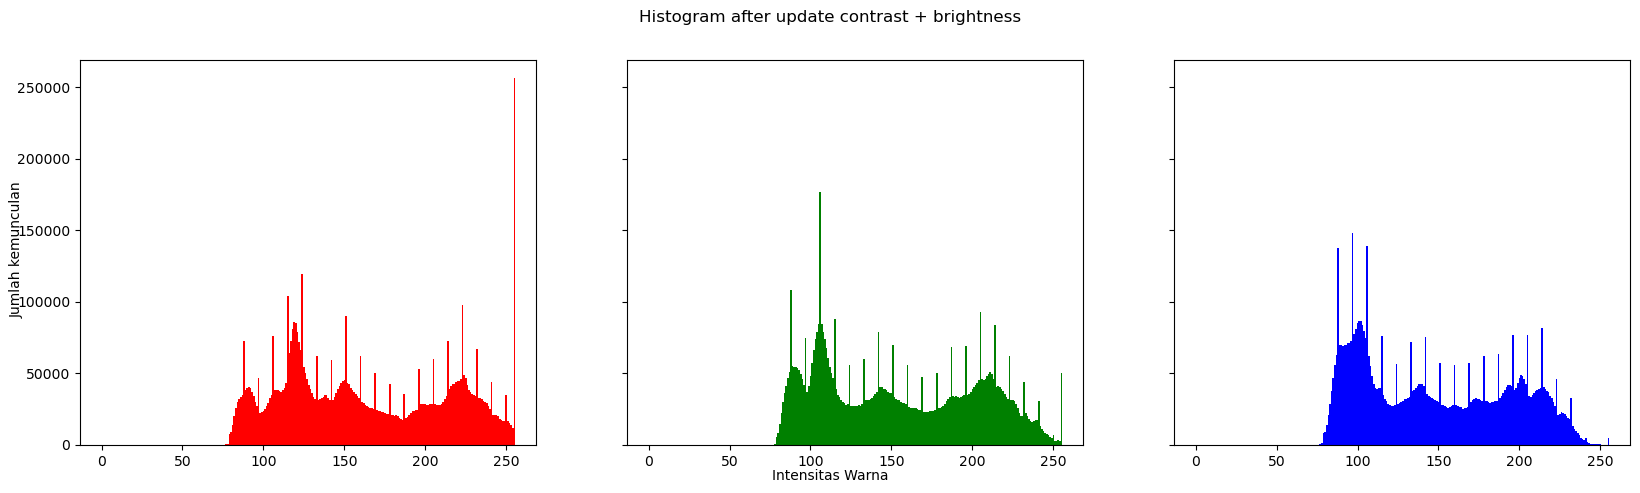

In [73]:
# 3rd image
img_3a = transformContrastBrightness(
    img_objs[2],
    alpha=0.9,
    beta=70
)

img_3a_rgb = cv2.cvtColor(img_3a, cv2.COLOR_BGR2RGB)

plt.imshow(img_3a_rgb)
plt.show()

visualize_histogram(img_objs[2], suptitle='Histogram original')
visualize_histogram(img_3a, suptitle='Histogram after update contrast + brightness')

## 3. Lakukan histogram equalization untuk memperbaiki sebaran kontras

Bandingkan hasil visual dan histogram sebelum–sesudah.

In [ ]:
def histogram_equalization(
    img: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    hist, bins = np.histogram(img.flatten(), bins=256, range=(0, 256))
    
    # Calculate cumulative distribution function (CDF)
    cdf = hist.cumsum()
    
    # Normalize CDF
    cdf_normalized = cdf * 255 / cdf[-1]
    
    equalized_img = np.interp(img.flatten(), bins[:-1], cdf_normalized).reshape(img.shape).astype(np.uint8)
    
    # Calculate histogram of equalized image
    equalized_hist, _ = np.histogram(equalized_img.flatten(), bins=256, range=(0, 256))
    
    return equalized_img, hist, equalized_hist

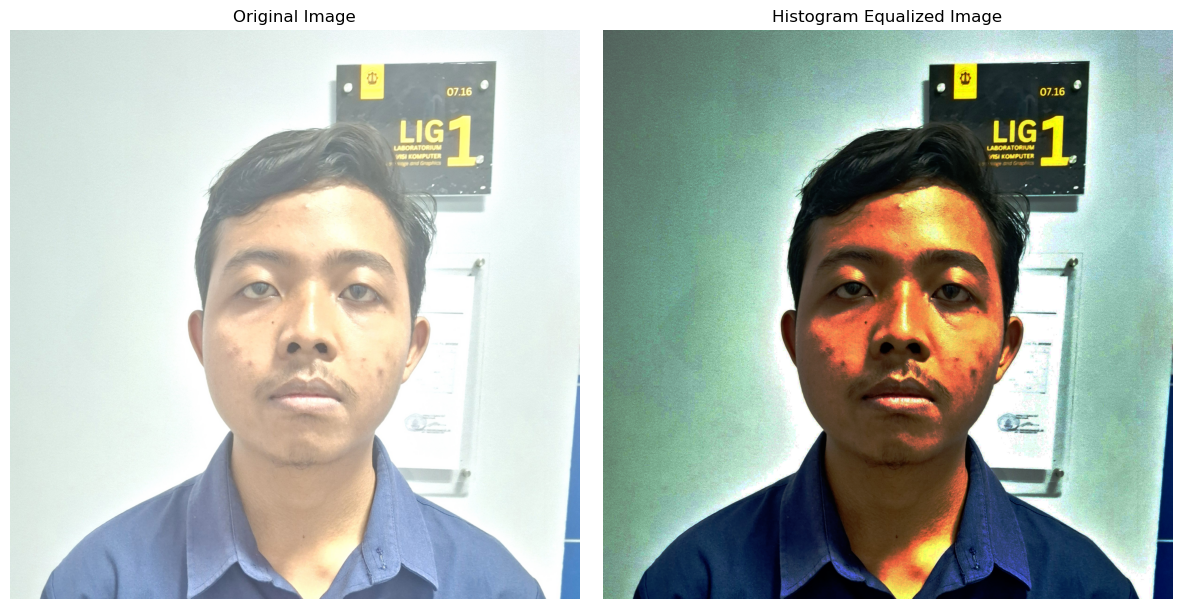

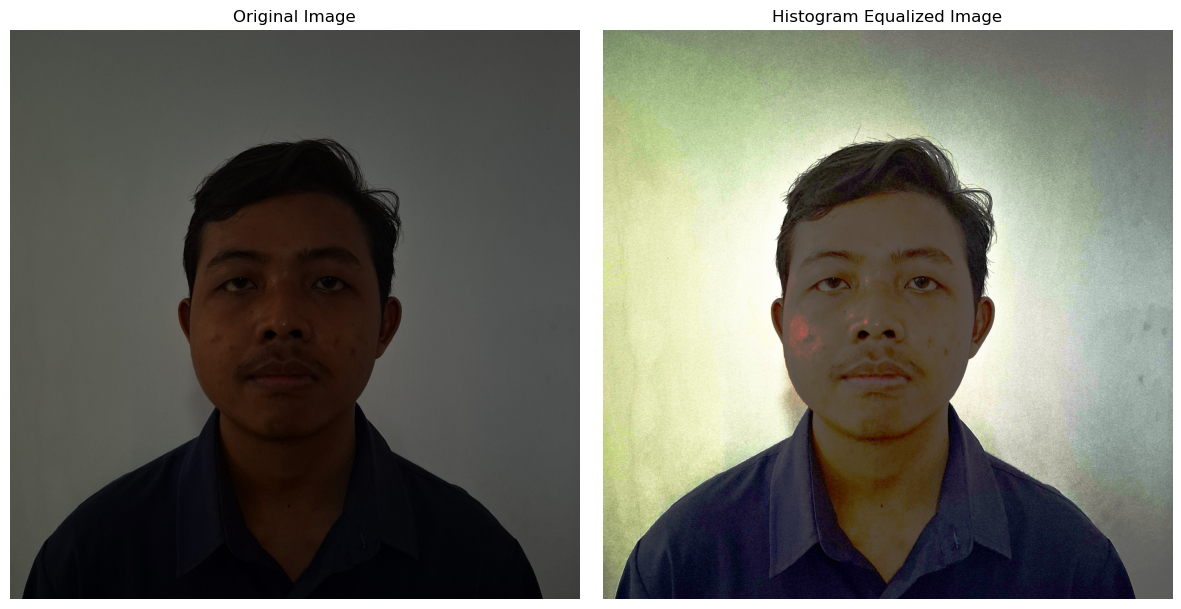

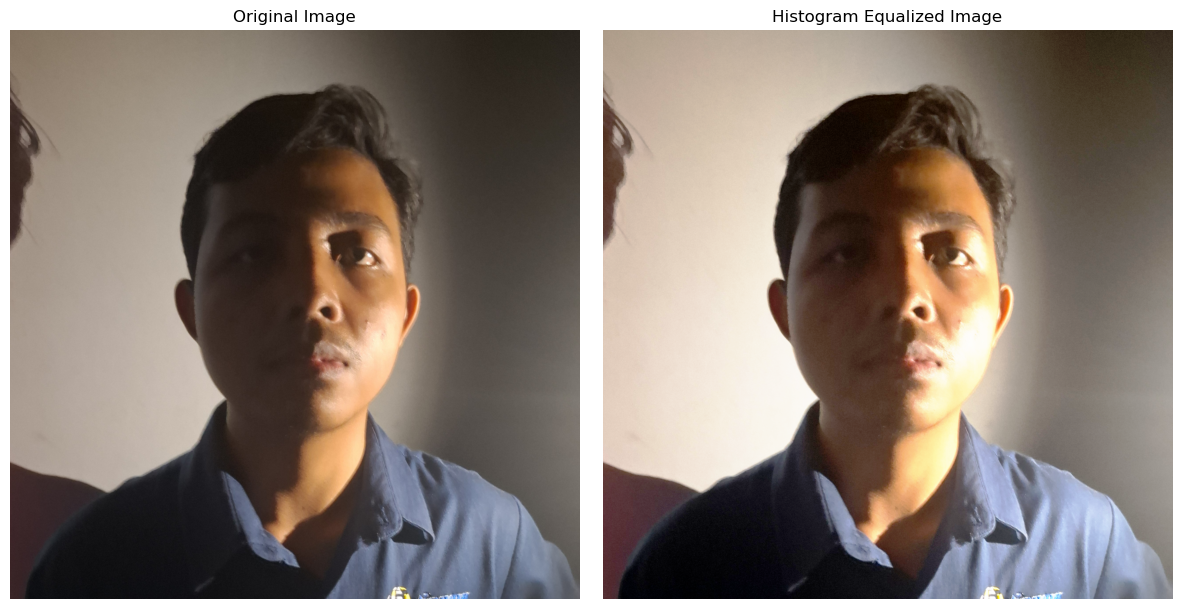

In [ ]:
for path in imgs_path:
    img = cv2.imread(path)
    
    if img is None:
        raise Exception('Image is not found!')
    
    equalized_img, original_hist, equalized_hist = histogram_equalization(img)
    
    # Convert BGR to RGB for matplotlib display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    equalized_img_rgb = cv2.cvtColor(equalized_img, cv2.COLOR_BGR2RGB)
    
    # Display images side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(equalized_img_rgb)
    axes[1].set_title('Histogram Equalized Image')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## 4. Terapkan filter spasial

- Low-pass filter untuk menghaluskan noise kulit wajah.
- High-pass atau Laplacian filter untuk menajamkan tepi mata dan bibir.

## 5. Implementasikan Floyd–Steinberg Dithering

Berguna untuk menurunkan kedalaman warna wajah (bit-depth 4–6 bit), lalu analisis bagaimana efeknya terhadap detail dan ekspresi wajah.

In [55]:
def floyd_steinberg_dithering(
    img: np.ndarray
) -> np.ndarray:
    """
    Apply Floyd-Steinberg dithering to a color image (OpenCV BGR format).
    Works on each channel independently.
    """
    arr = img.astype(np.float32)
    h, w, c = arr.shape

    for y in range(h):
        for x in range(w):
            old_pixel = arr[y, x].copy()
            new_pixel = np.where(old_pixel < 128, 0, 255)
            arr[y, x] = new_pixel
            quant_error = old_pixel - new_pixel

            # Spread the error (per channel)
            if x + 1 < w:
                arr[y, x+1] += quant_error * 7/16
            if y + 1 < h and x - 1 >= 0:
                arr[y+1, x-1] += quant_error * 3/16
            if y + 1 < h:
                arr[y+1, x] += quant_error * 5/16
            if y + 1 < h and x + 1 < w:
                arr[y+1, x+1] += quant_error * 1/16

    return np.clip(arr, 0, 255).astype(np.uint8)

In [58]:
def floyd_steinberg_dithering_fast(img: np.ndarray) -> np.ndarray:
    """
    Faster Floyd–Steinberg dithering using NumPy row-wise vectorization.
    Works on BGR images (uint8).
    """
    arr = img.astype(np.float32)
    h, w, c = arr.shape

    for y in range(h - 1):  # last row handled separately
        # Quantize current row
        old_row = arr[y].copy()
        new_row = np.where(old_row < 128, 0, 255)
        arr[y] = new_row
        quant_error = old_row - new_row

        # Spread errors (vectorized within the row)
        if w > 1:
            arr[y, 1:w] += quant_error[:, :-1] * (7 / 16)  # right
        arr[y + 1, :-1] += quant_error[:, 1:] * (3 / 16)  # bottom-left
        arr[y + 1] += quant_error * (5 / 16)              # bottom
        arr[y + 1, 1:] += quant_error[:, :-1] * (1 / 16)  # bottom-right

    # Handle last row (no diffusion below)
    old_row = arr[-1].copy()
    new_row = np.where(old_row < 128, 0, 255)
    arr[-1] = new_row

    return np.clip(arr, 0, 255).astype(np.uint8)

In [60]:
def floyd_steinberg_dithering_fast(img: np.ndarray) -> np.ndarray:
    """
    Faster and safe Floyd–Steinberg dithering using NumPy row-wise vectorization.
    Works for grayscale or color images (OpenCV format).
    """
    arr = img.astype(np.float32)
    if arr.ndim == 2:
        h, w = arr.shape
        c = 1
        arr = arr[..., np.newaxis]  # add channel dimension
    else:
        h, w, c = arr.shape

    for y in range(h - 1):
        old_row = arr[y].copy()
        new_row = np.where(old_row < 128, 0, 255)
        arr[y] = new_row
        quant_error = old_row - new_row

        # Right pixel (same row)
        arr[y, 1:w] += quant_error[:w-1] * (7 / 16)

        # Bottom-left
        arr[y + 1, :w-1] += quant_error[1:w] * (3 / 16)

        # Bottom
        arr[y + 1] += quant_error * (5 / 16)

        # Bottom-right
        arr[y + 1, 1:w] += quant_error[:w-1] * (1 / 16)

    # Last row (no diffusion)
    old_row = arr[-1].copy()
    new_row = np.where(old_row < 128, 0, 255)
    arr[-1] = new_row

    result = np.clip(arr, 0, 255).astype(np.uint8)
    if c == 1:
        result = result.squeeze()  # remove channel dimension for grayscale
    return result


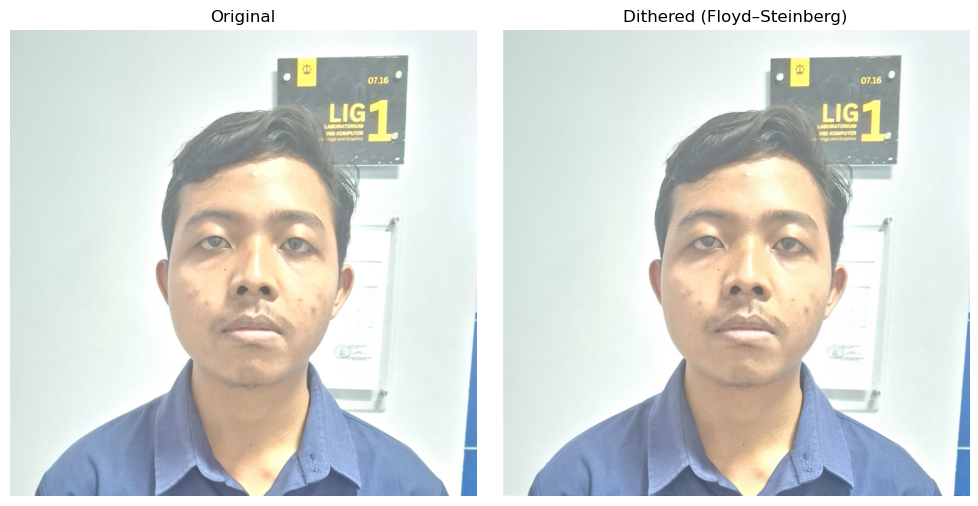

In [62]:
dithered = floyd_steinberg_dithering_fast(img_objs[0])

img_0_rgb = cv2.cvtColor(img_objs[0], cv2.COLOR_BGR2RGB)
dithered_rgb = cv2.cvtColor(dithered, cv2.COLOR_BGR2RGB)

# Show results with matplotlib
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img_0_rgb, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Dithered (Floyd–Steinberg)")
plt.imshow(dithered_rgb, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

---

# Bagian B - Analisis

1. Bagaimana perubahan nilai brightness dan contrast memengaruhi hasil histogram wajah
gelap?

    Jawab: Perubahan nilai brightness dan contrast dari gambar mempengaruhi persebaran dari histogram dari gambar yang asli.

2. Apakah histogram equalization selalu memperbaiki detail wajah? Jelaskan alasannya dengan
contoh hasil Anda.

    Jawab: 

3. Bandingkan hasil low-pass dan high-pass filter pada area wajah — bagian mana yang paling
terpengaruh?

    Jawab:

4. Mengapa proses dithering bisa mempertegas atau justru mengaburkan ekspresi wajah?

    Jawab:

5. Berdasarkan hasil percobaan Anda, kombinasi teknik mana yang paling efektif untuk
meningkatkan readability fitur wajah sebelum tahap deteksi?

    Jawab:

---

# Bagian C - Implementasi (PyThon - OpenCV)

```py
import cv2, numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('face1.jpg', cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Brightness & Contrast
b, a = 30, 1.2
img_bc = cv2.convertScaleAbs(gray, alpha=a, beta=b)

# Histogram Equalization
img_he = cv2.equalizeHist(img_bc)

# Spatial Filtering (contoh High-pass)
kernel_hp = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
img_hp = cv2.filter2D(img_he, -1, kernel_hp)
```

Kemudian tampilkan hasil 4 tahap (asli → BC → HE → Filter → Dithered)

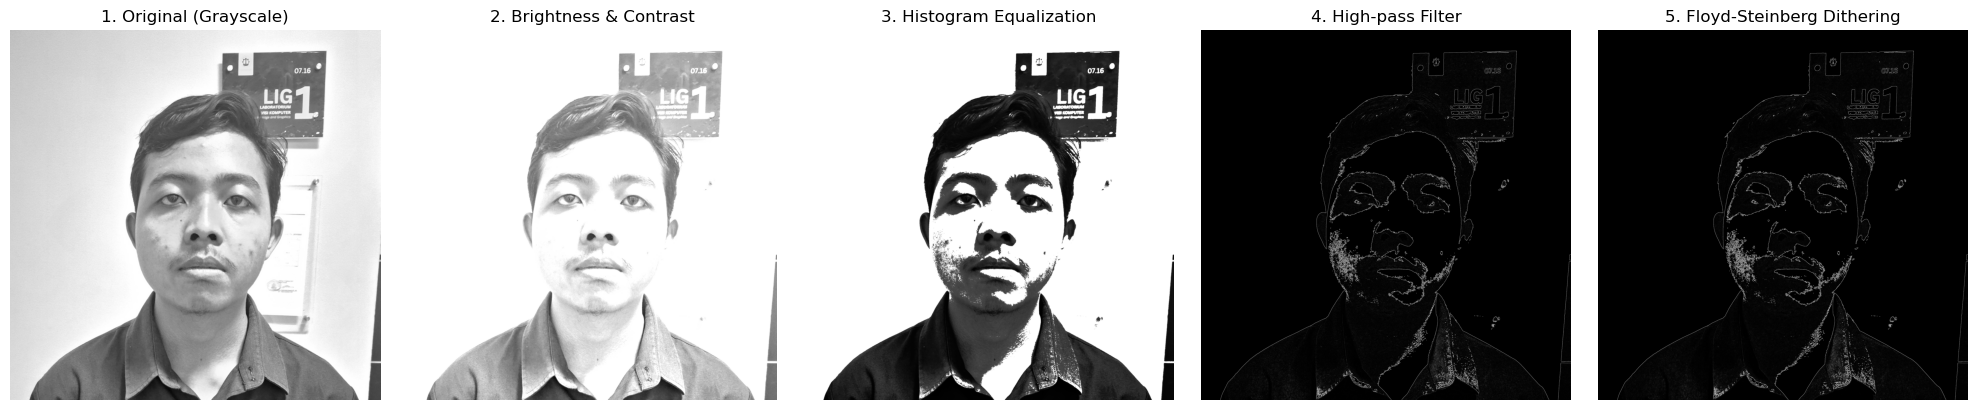

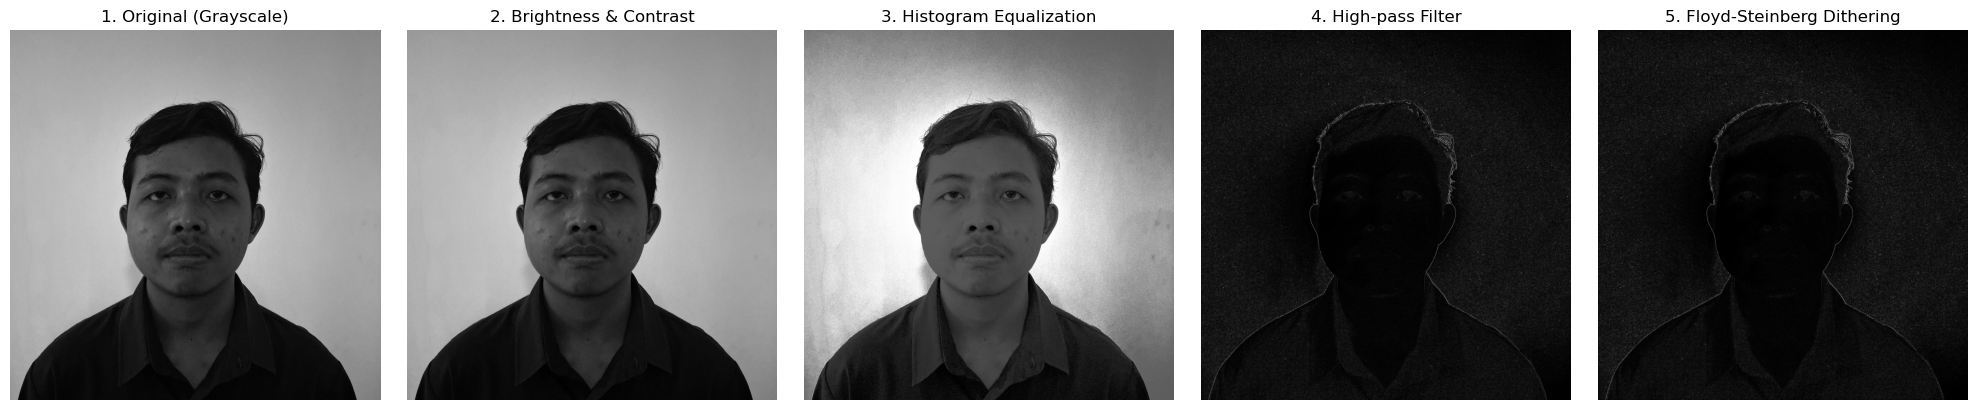

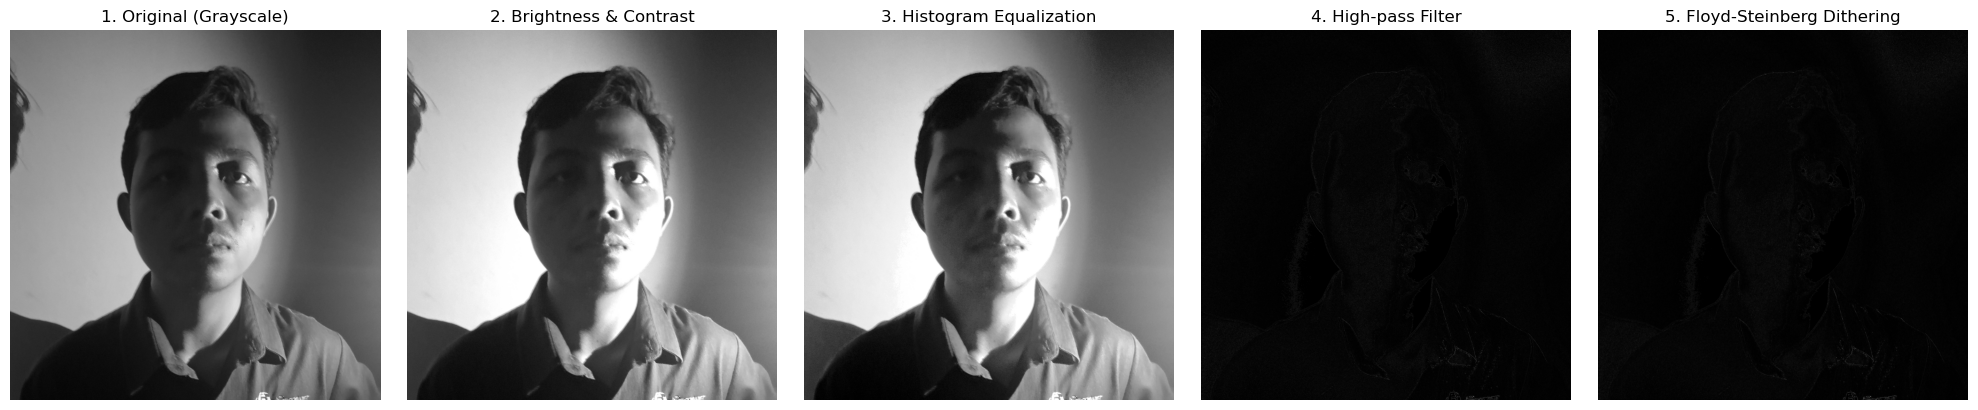

In [67]:
for path in imgs_path:
    img_test = cv2.imread(path, cv2.IMREAD_COLOR)
    gray = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY) # type: ignore

    # Brightness & Contrast
    img_bc = cv2.convertScaleAbs(gray, alpha=1.2, beta=30)

    # Histogram Equalization
    img_he = cv2.equalizeHist(img_bc)

    # Spatial Filtering (contoh High-pass)
    kernel_hp = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    img_hp = cv2.filter2D(img_he, -1, kernel_hp)

    # Floyd-Steinberg Dithering
    img_dithered = floyd_steinberg_dithering_fast(img_hp)

    # Visualization
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title('1. Original (Grayscale)')
    axes[0].axis('off')

    axes[1].imshow(img_bc, cmap='gray')
    axes[1].set_title('2. Brightness & Contrast')
    axes[1].axis('off')

    axes[2].imshow(img_he, cmap='gray')
    axes[2].set_title('3. Histogram Equalization')
    axes[2].axis('off')

    axes[3].imshow(img_hp, cmap='gray')
    axes[3].set_title('4. High-pass Filter')
    axes[3].axis('off')

    axes[4].imshow(img_dithered, cmap='gray')
    axes[4].set_title('5. Floyd-Steinberg Dithering')
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()

---

# Bagian D - Analisis Akhir dan Kesimpulan